# NASA Milling: Case 1 sensor features and tool-wear baselines

By Songjiang Cai. Publication edition of an ongoing learning project.

This notebook organises the existing exploratory work. It extracts mean and standard deviation from spindle vibration and AE, fits individual linear baselines, and inspects residuals. **There is no independent test set in this edition.**

Dataset: [NASA PCoE Milling](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/). Download separately and place `mill.mat` in `data/`.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image

# Works from the repository root, its notebooks/ folder, or /content in Colab.
ROOT = next((p for p in [Path.cwd(), Path.cwd().parent,
                        Path.cwd() / "nasa-milling-tool-wear"]
             if (p / "src" / "analysis.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Extract the project package first; see docs/SETUP_ZH.md.")
sys.path.insert(0, str(ROOT / "src"))
from analysis import load_features, fit_baselines, save_figures, window_mask
DATA_PATH = ROOT / "data" / "mill.mat"


## Load records and compute features

Only Case 1 records with finite VB labels are used for fitting. **VB = 0 is retained.** `record_number` is the position in the entire dataset; `run` is the actual per-case identifier.

The window preserves the original mask `t = np.arange(9000) * 36 / 9000; (t > 10) & (t < 25)`. Its physical time scale is unverified, so we express it by sample location. For a 9000-sample signal, it selects zero-based indices 2501 through 6249. The same fractions are used for both channels. This is a provisional feature window, not a universally validated stable cutting interval.

Mean: arithmetic average. Standard deviation: `np.std(..., ddof=0)`.


In [2]:
mill, features = load_features(DATA_PATH, case_id=1)
print("Dataset records:", len(mill))
print("Labelled Case 1 records:", len(features))
display(features)


Dataset records: 167
Labelled Case 1 records: 13


,record_number,case,run,VB,vib_mean,vib_std,AE_mean,AE_std
0,1,1,1,0.00,0.648509,0.078750,0.209068,0.037541
1,4,1,4,0.11,0.586600,0.060225,0.227271,0.038139
2,6,1,6,0.20,0.524458,0.036511,0.237914,0.030290
3,7,1,7,0.24,0.443222,0.030803,0.333051,0.049276
4,8,1,8,0.29,0.442355,0.032362,0.292756,0.036115
5,9,1,9,0.28,0.441375,0.027858,0.384274,0.054352
6,10,1,10,0.29,0.407035,0.025583,0.339209,0.039691
7,11,1,11,0.38,0.383948,0.023873,0.425877,0.051597
8,12,1,12,0.40,0.481121,0.035500,0.387235,0.047492
9,13,1,13,0.43,0.393711,0.021022,0.387914,0.049563


## Correlation is descriptive

Pearson correlation measures linear association within the selected records. It does not establish a causal relationship or performance on other cases.


In [3]:
display(features[["VB", "vib_mean", "vib_std", "AE_mean", "AE_std"]].corr()[["VB"]])


,VB
VB,1.000000
vib_mean,-0.862647
vib_std,-0.833915
AE_mean,0.911328
AE_std,0.703800


## Individual linear baselines

For a feature x, fit `VB_hat = a*x + b` using least squares. The feature is the input; VB is the target. These are separate single-feature models, not a multivariable plane.

`residual = VB - VB_hat`; `MAE = mean(abs(residual))`.

**The same records are used to fit and calculate MAE. These are fitting diagnostics, not validation results.**


In [4]:
# Explicit example: predicting VB from AE mean.
a_AE, b_AE = np.polyfit(features["AE_mean"], features["VB"], 1)
print("AE model slope and intercept:", a_AE, b_AE)

metrics, residuals = fit_baselines(features)
display(metrics)
display(residuals)


AE model slope and intercept: 1.449899895304022 -0.20573826828143177


,feature,pearson_r,slope,intercept,fit_MAE,evaluation
0,vib_mean,-0.862647,-1.568024,1.030738,0.057829,in-sample; no independent test set
1,vib_std,-0.833915,-7.301006,0.563521,0.065038,in-sample; no independent test set
2,AE_mean,0.911328,1.449900,-0.205738,0.051077,in-sample; no independent test set


,record_number,case,run,VB,vib_mean_estimate,vib_mean_residual,vib_std_estimate,vib_std_residual,AE_mean_estimate,AE_mean_residual
0,1,1,1,0.00,0.013861,-0.013861,-0.011435,0.011435,0.097389,-0.097389
1,4,1,4,0.11,0.110936,-0.000936,0.123821,-0.013821,0.123782,-0.013782
2,6,1,6,0.20,0.208376,-0.008376,0.296953,-0.096953,0.139213,0.060787
3,7,1,7,0.24,0.335755,-0.095755,0.338626,-0.098626,0.277153,-0.037153
4,8,1,8,0.29,0.337116,-0.047116,0.327248,-0.037248,0.218729,0.071271
5,9,1,9,0.28,0.338652,-0.058652,0.360131,-0.080131,0.351420,-0.071420
6,10,1,10,0.29,0.392497,-0.102497,0.376742,-0.086742,0.286081,0.003919
7,11,1,11,0.38,0.428699,-0.048699,0.389223,-0.009223,0.411740,-0.031740
8,12,1,12,0.40,0.276329,0.123671,0.304332,0.095668,0.355714,0.044286
9,13,1,13,0.43,0.413390,0.016610,0.410042,0.019958,0.356698,0.073302


## Inspect signals, feature relationships, and residuals

Plots use actual per-case run IDs. All unusual records remain included; no point is removed simply to improve the fit. The signal comparison illustrates runs around a feature deviation; it does not prove a sensor fault.


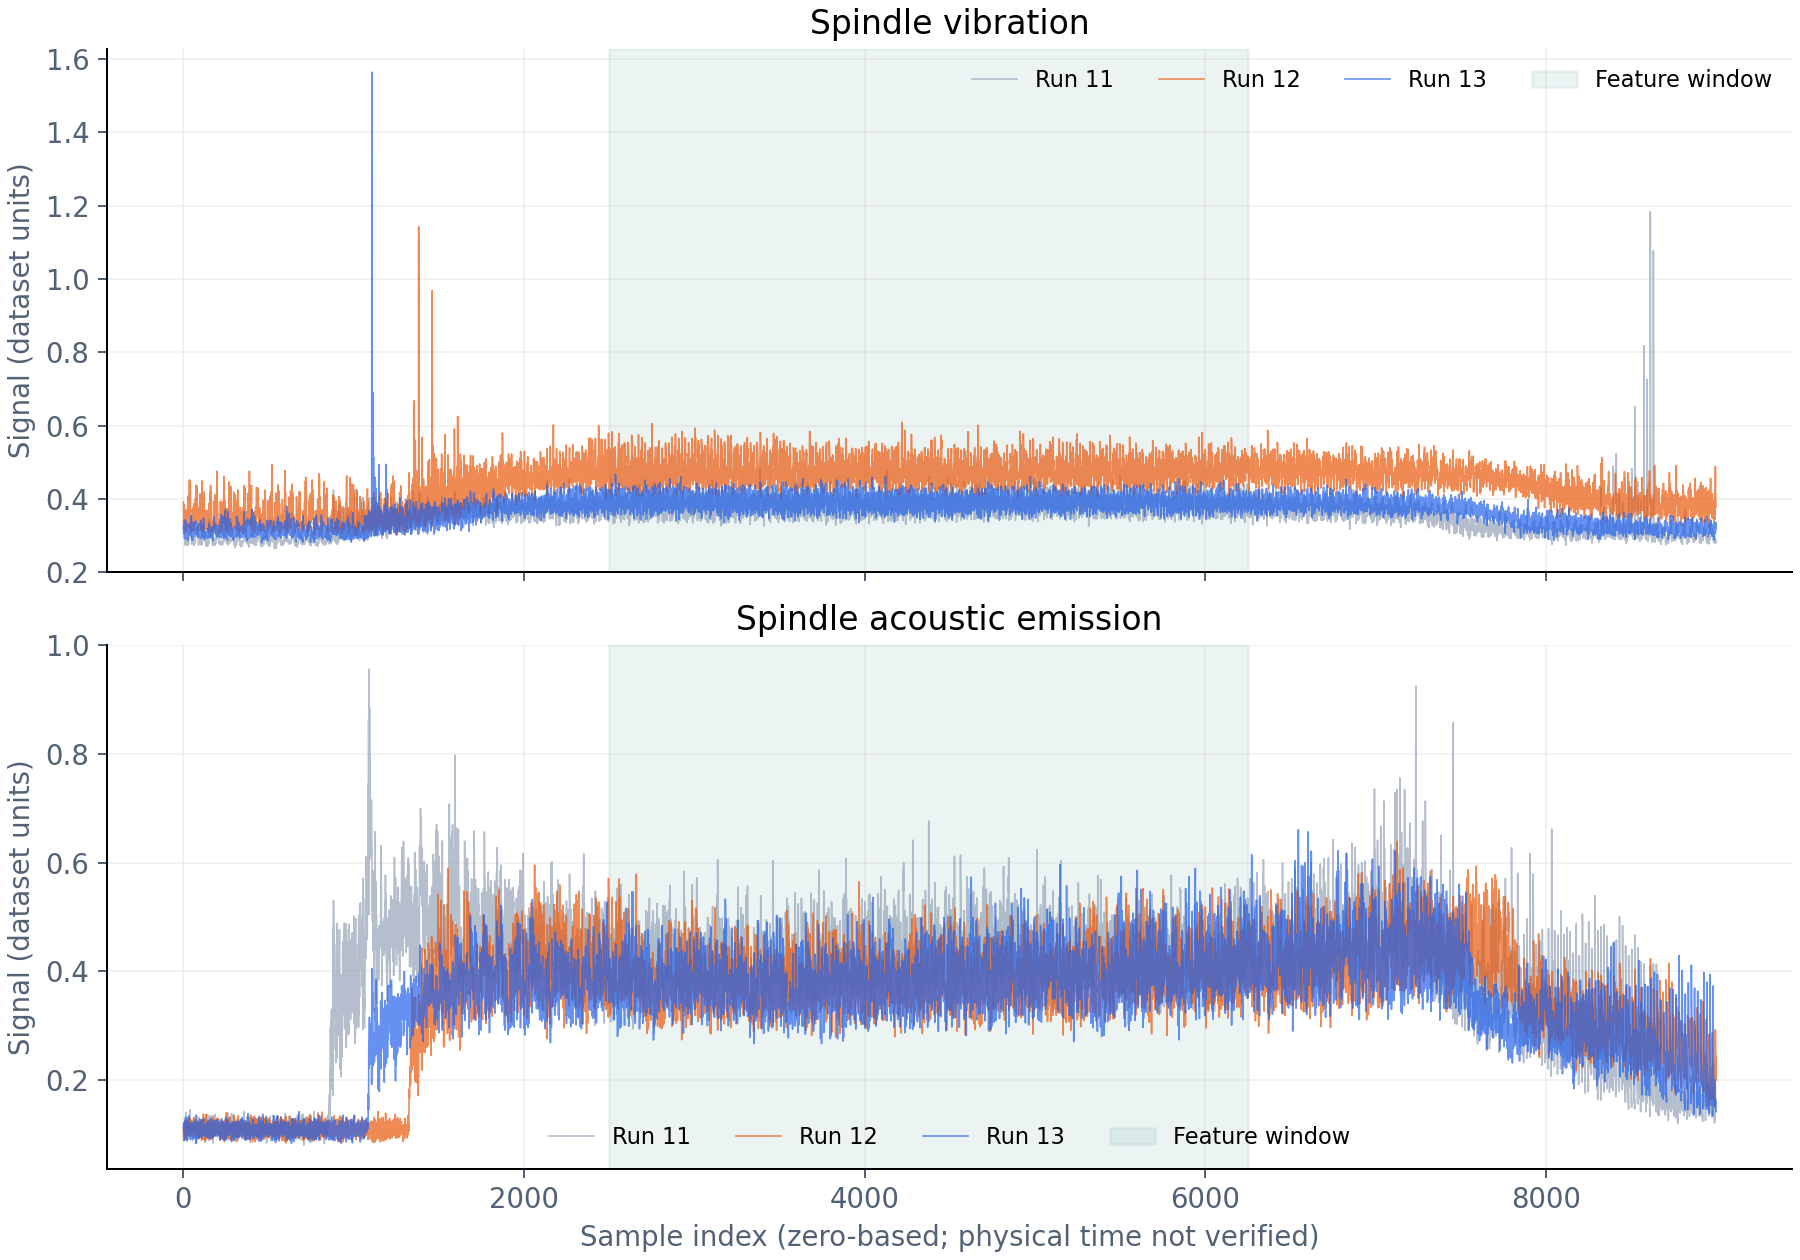

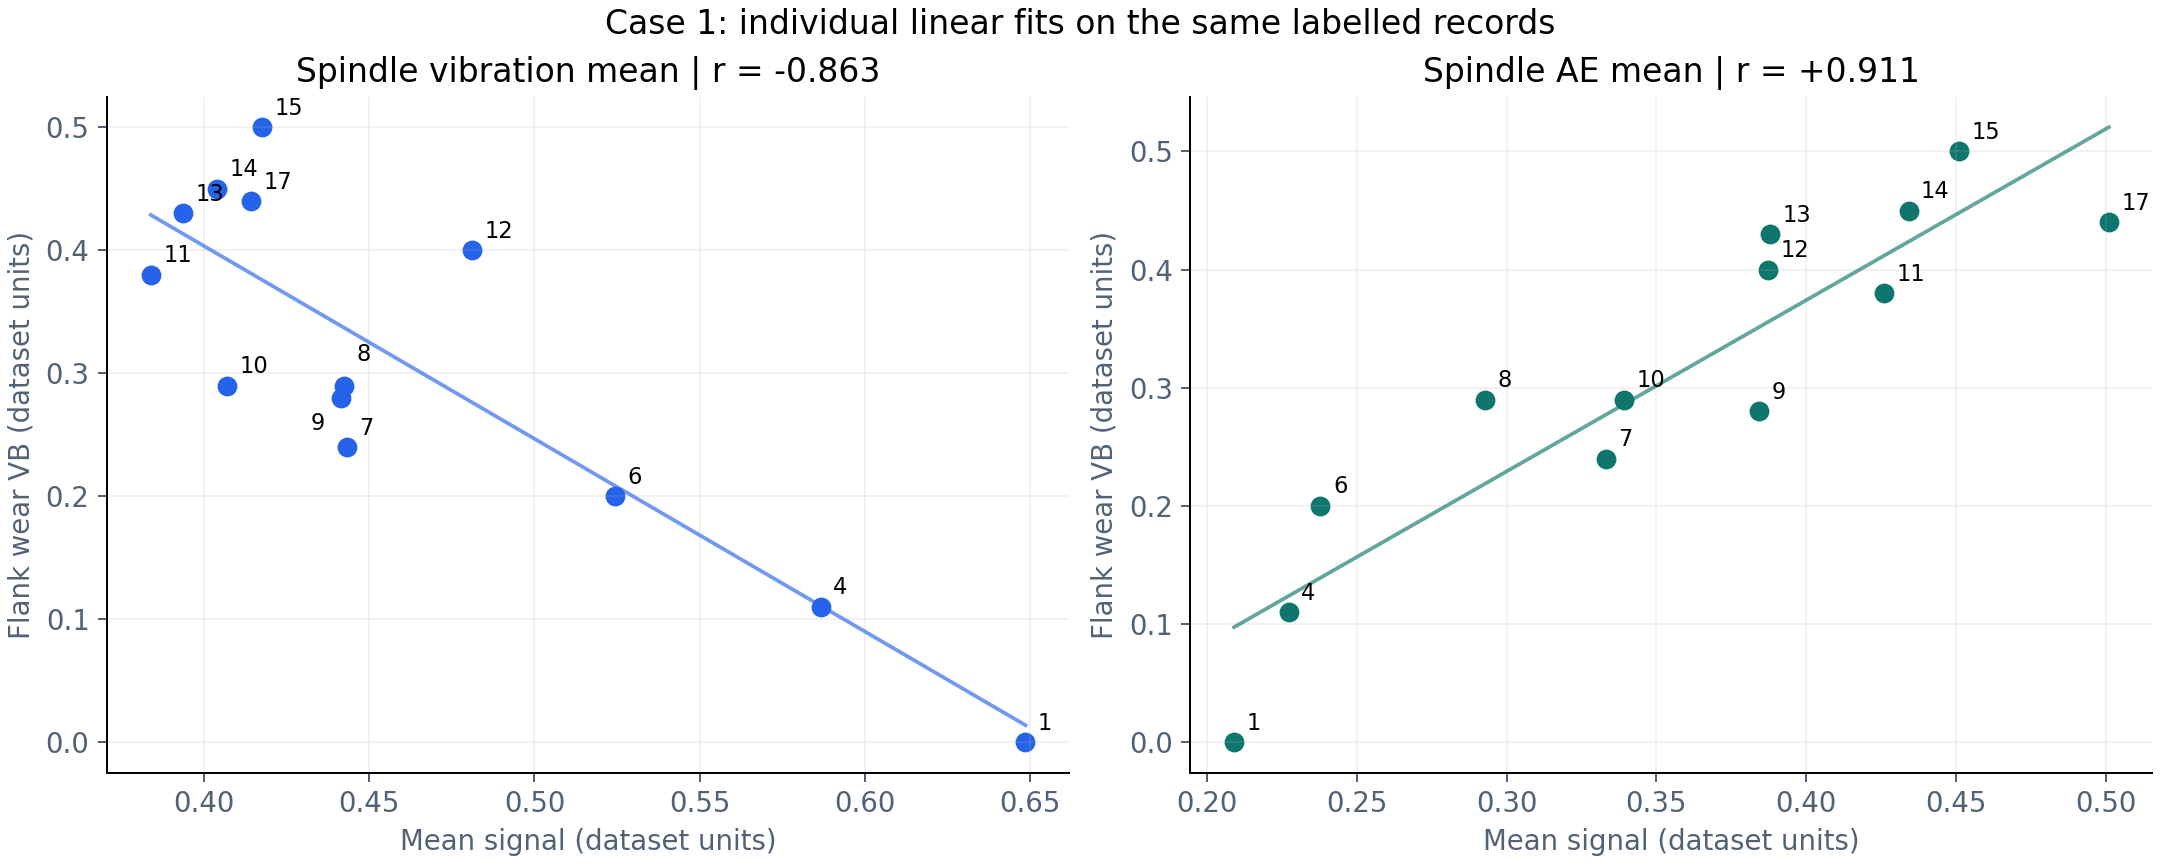

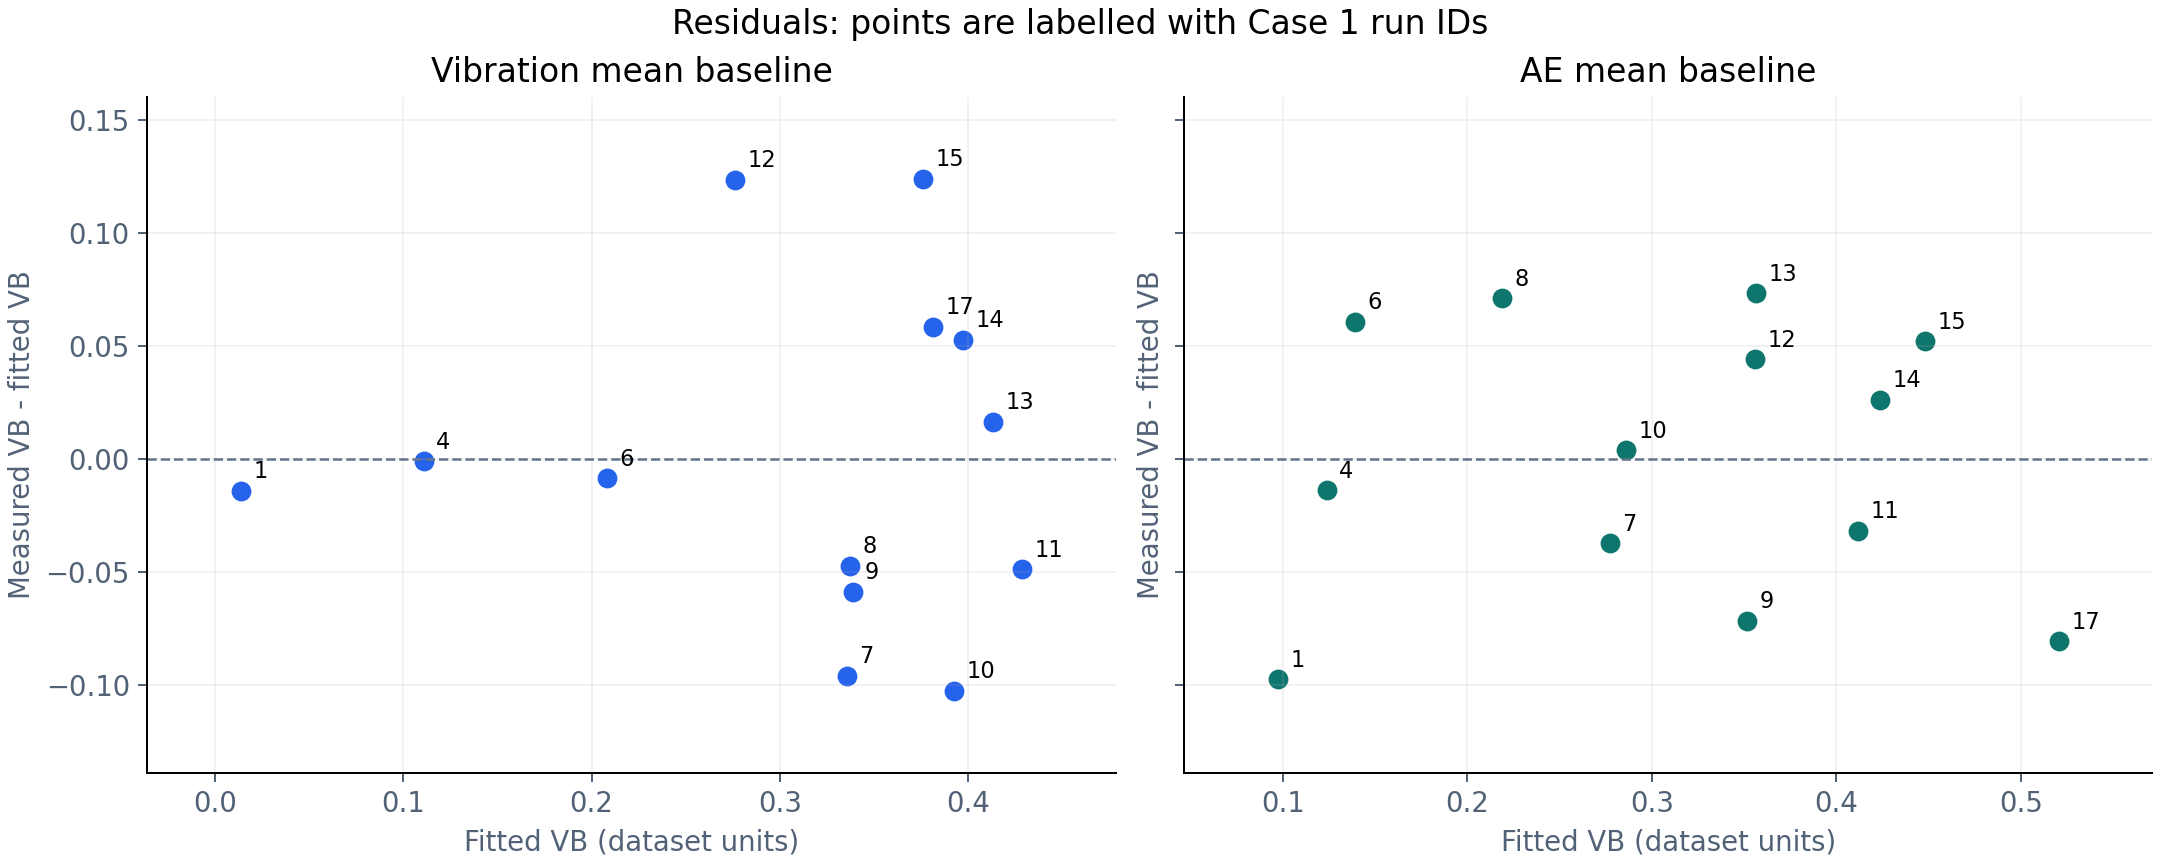

In [5]:
save_figures(mill, features, metrics, residuals, ROOT / "figures")
for filename in ["signal_window.png", "feature_relationships.png", "residual_comparison.png"]:
    display(Image(filename=str(ROOT / "figures" / filename)))


## Export the tables

These exports are the source for the README and publication figures. Use the command-line script to also write the full provenance file.


In [6]:
output = ROOT / "results"
output.mkdir(exist_ok=True)
features.to_csv(output / "case1_features.csv", index=False)
metrics.to_csv(output / "baseline_metrics.csv", index=False)
residuals.to_csv(output / "case1_residuals.csv", index=False)


## Interpretation and next steps

AE mean has a lower in-sample MAE than vibration mean in this case. That is a reason to investigate it further, not evidence that it will perform better on unseen runs.

Planned work: combine the two means; evaluate whether standard deviation adds useful information; compare against a simple baseline on held-out runs; later test other cases with a split suited to the intended use. No multivariable or machine-learning model has been validated in this release.

Before claiming physical time or frequency features, verify original acquisition documentation. Revisit the window for other cases and channels rather than automatically reusing it.

## Personal reflection

<!-- Add your own reflection here: what you expected, what surprised you, and what you would change. -->
